In [ ]:
# Step 1 Dataset Overview

import pandas as pd

df = pd.read_csv("10_Property_stolen_and_recovered.csv")

print("First 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())

print("\nShape of dataset:", df.shape)

print("\nColumn Names:", df.columns.tolist())

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

print("\nUnique Values in Each Column:\n", df.nunique())



First 5 Rows:
                    Area_Name    Year           Group_Name Sub_Group_Name  \
0  Andaman & Nicobar Islands  2001.0  Burglary - Property    3. Burglary   
1             Andhra Pradesh  2001.0  Burglary - Property    3. Burglary   
2          Arunachal Pradesh  2001.0  Burglary - Property    3. Burglary   
3                      Assam  2001.0  Burglary - Property    3. Burglary   
4                      Bihar  2001.0  Burglary - Property    3. Burglary   

   Cases_Property_Recovered  Cases_Property_Stolen  \
0                      27.0                     64   
1                    3321.0                   7134   
2                      66.0                    248   
3                     539.0                   2423   
4                     367.0                   3231   

   Value_of_Property_Recovered  Value_of_Property_Stolen  
0                     755858.0                   1321961  
1                   51483437.0                 147019348  
2                     8251

In [ ]:
# Step 2  Data quality checks

# Find missing values
print("Missing values:\n", df.isnull().sum())

# Detect duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check for negative or invalid numeric values
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    if (df[col] < 0).any():
        print(f"Invalid negative values found in column: {col}")

# Check for formatting issues (extra spaces or inconsistent cases)
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().str.title()


Missing values:
 Area_Name                      0
Year                           1
Group_Name                     0
Sub_Group_Name                 0
Cases_Property_Recovered       1
Cases_Property_Stolen          0
Value_of_Property_Recovered    1
Value_of_Property_Stolen       0
dtype: int64

Duplicate Rows: 0
Invalid negative values found in column: Cases_Property_Recovered
Invalid negative values found in column: Cases_Property_Stolen
Invalid negative values found in column: Value_of_Property_Stolen


In [ ]:
#Step 3 Data cleaning

import numpy as np

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in obj_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.drop_duplicates(inplace=True)

print("Missing values handled and duplicates removed.")

Missing values handled and duplicates removed.


In [ ]:
# Step 4  Descriptive Statistics

print("\n--- Descriptive Statistics ---\n")
print(df.describe())

for col in num_cols:
    print(f"{col}: Skewness = {df[col].skew():.2f}, Kurtosis = {df[col].kurt():.2f}")

for col in obj_cols:
    print(f"\nValue counts for {col}:\n", df[col].value_counts().head())



--- Descriptive Statistics ---

              Year  Cases_Property_Recovered  Cases_Property_Stolen  \
count  2449.000000               2449.000000            2449.000000   
mean   2005.501225               1232.901184            3419.420171   
std       2.871854               3079.571153            8136.257163   
min    2001.000000                -42.000000              -1.000000   
25%    2003.000000                 13.000000              45.000000   
50%    2005.500000                113.000000             358.000000   
75%    2008.000000                722.000000            1875.000000   
max    2010.000000              27960.000000           80663.000000   

       Value_of_Property_Recovered  Value_of_Property_Stolen  
count                 2.449000e+03              2.449000e+03  
mean                  5.860092e+07              2.465380e+08  
std                   2.494399e+08              9.670048e+08  
min                   0.000000e+00             -6.259345e+06  
25%         

In [ ]:
# Step 5  Data Transformation & Encoding

from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
for col in obj_cols:
    df[col] = encoder.fit_transform(df[col])

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("✅ Data transformation and encoding completed.")


✅ Data transformation and encoding completed.


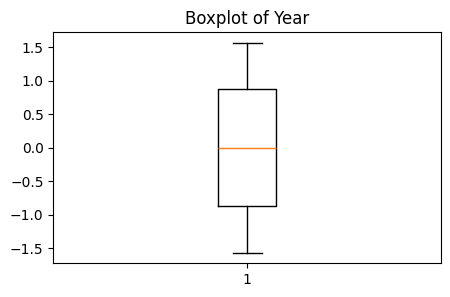

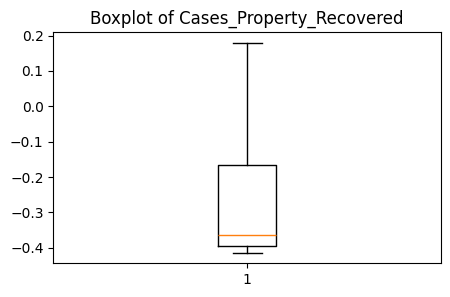

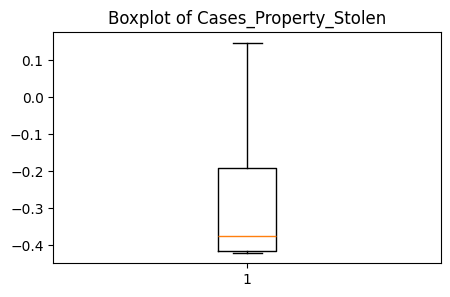

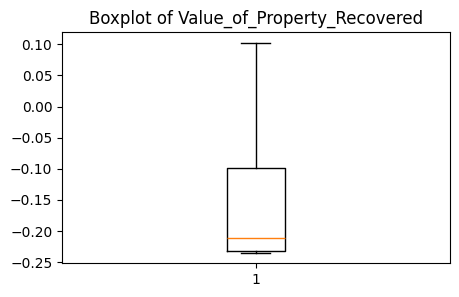

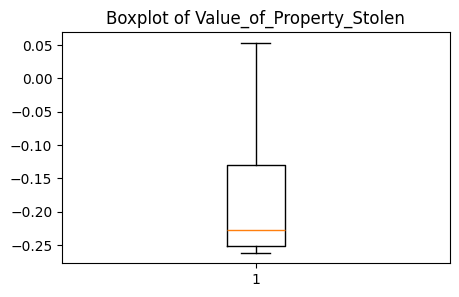

✅ Outliers detected and treated using IQR method.


In [ ]:
# Step 6  Outlier Detection & Treatment
import matplotlib.pyplot as plt

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

print("✅ Outliers detected and treated using IQR method.")


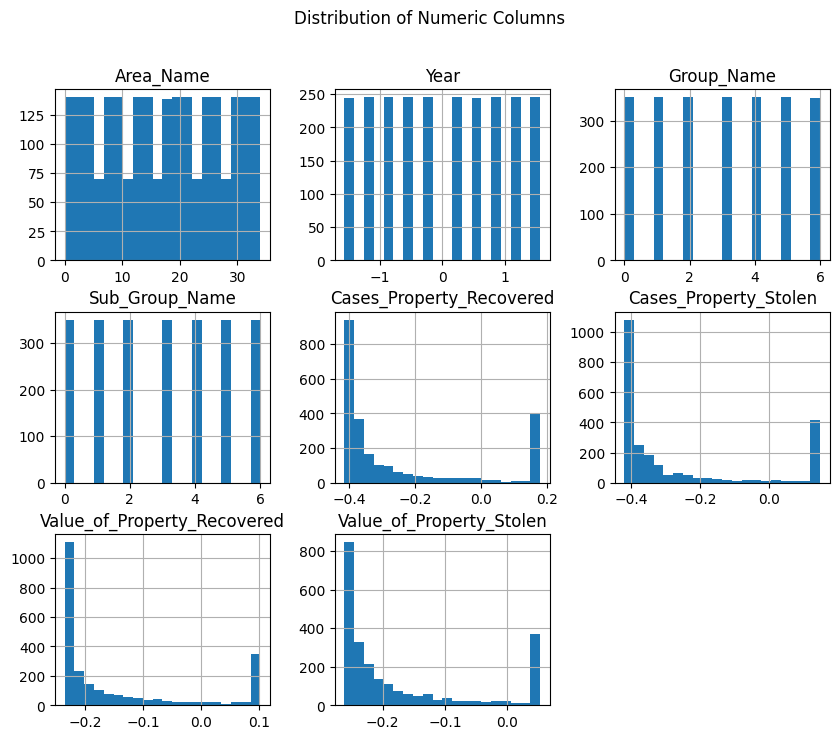

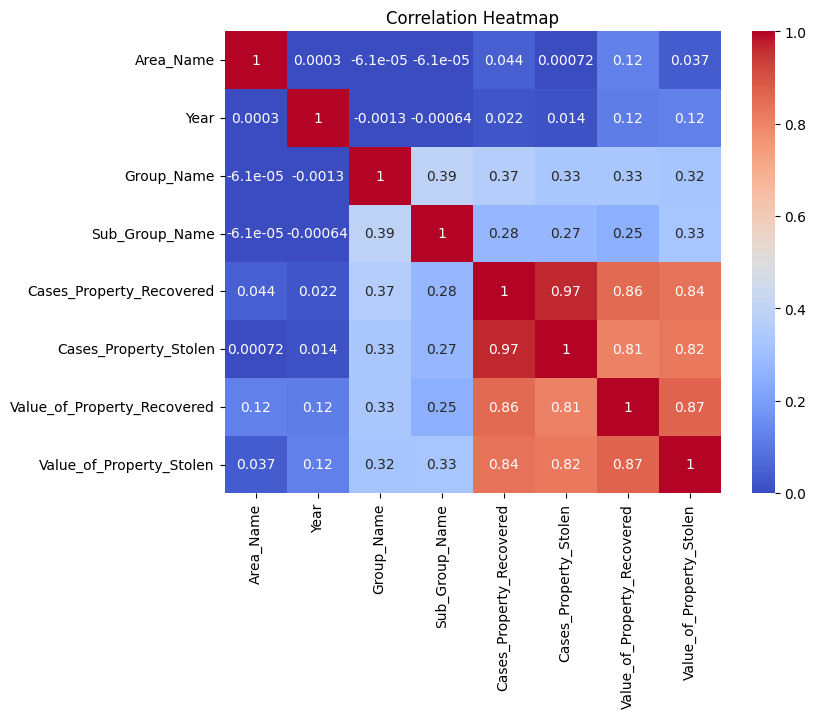

In [ ]:
# Step 7  Data Visualization
import seaborn as sns

df.hist(figsize=(10,8), bins=20)
plt.suptitle("Distribution of Numeric Columns")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


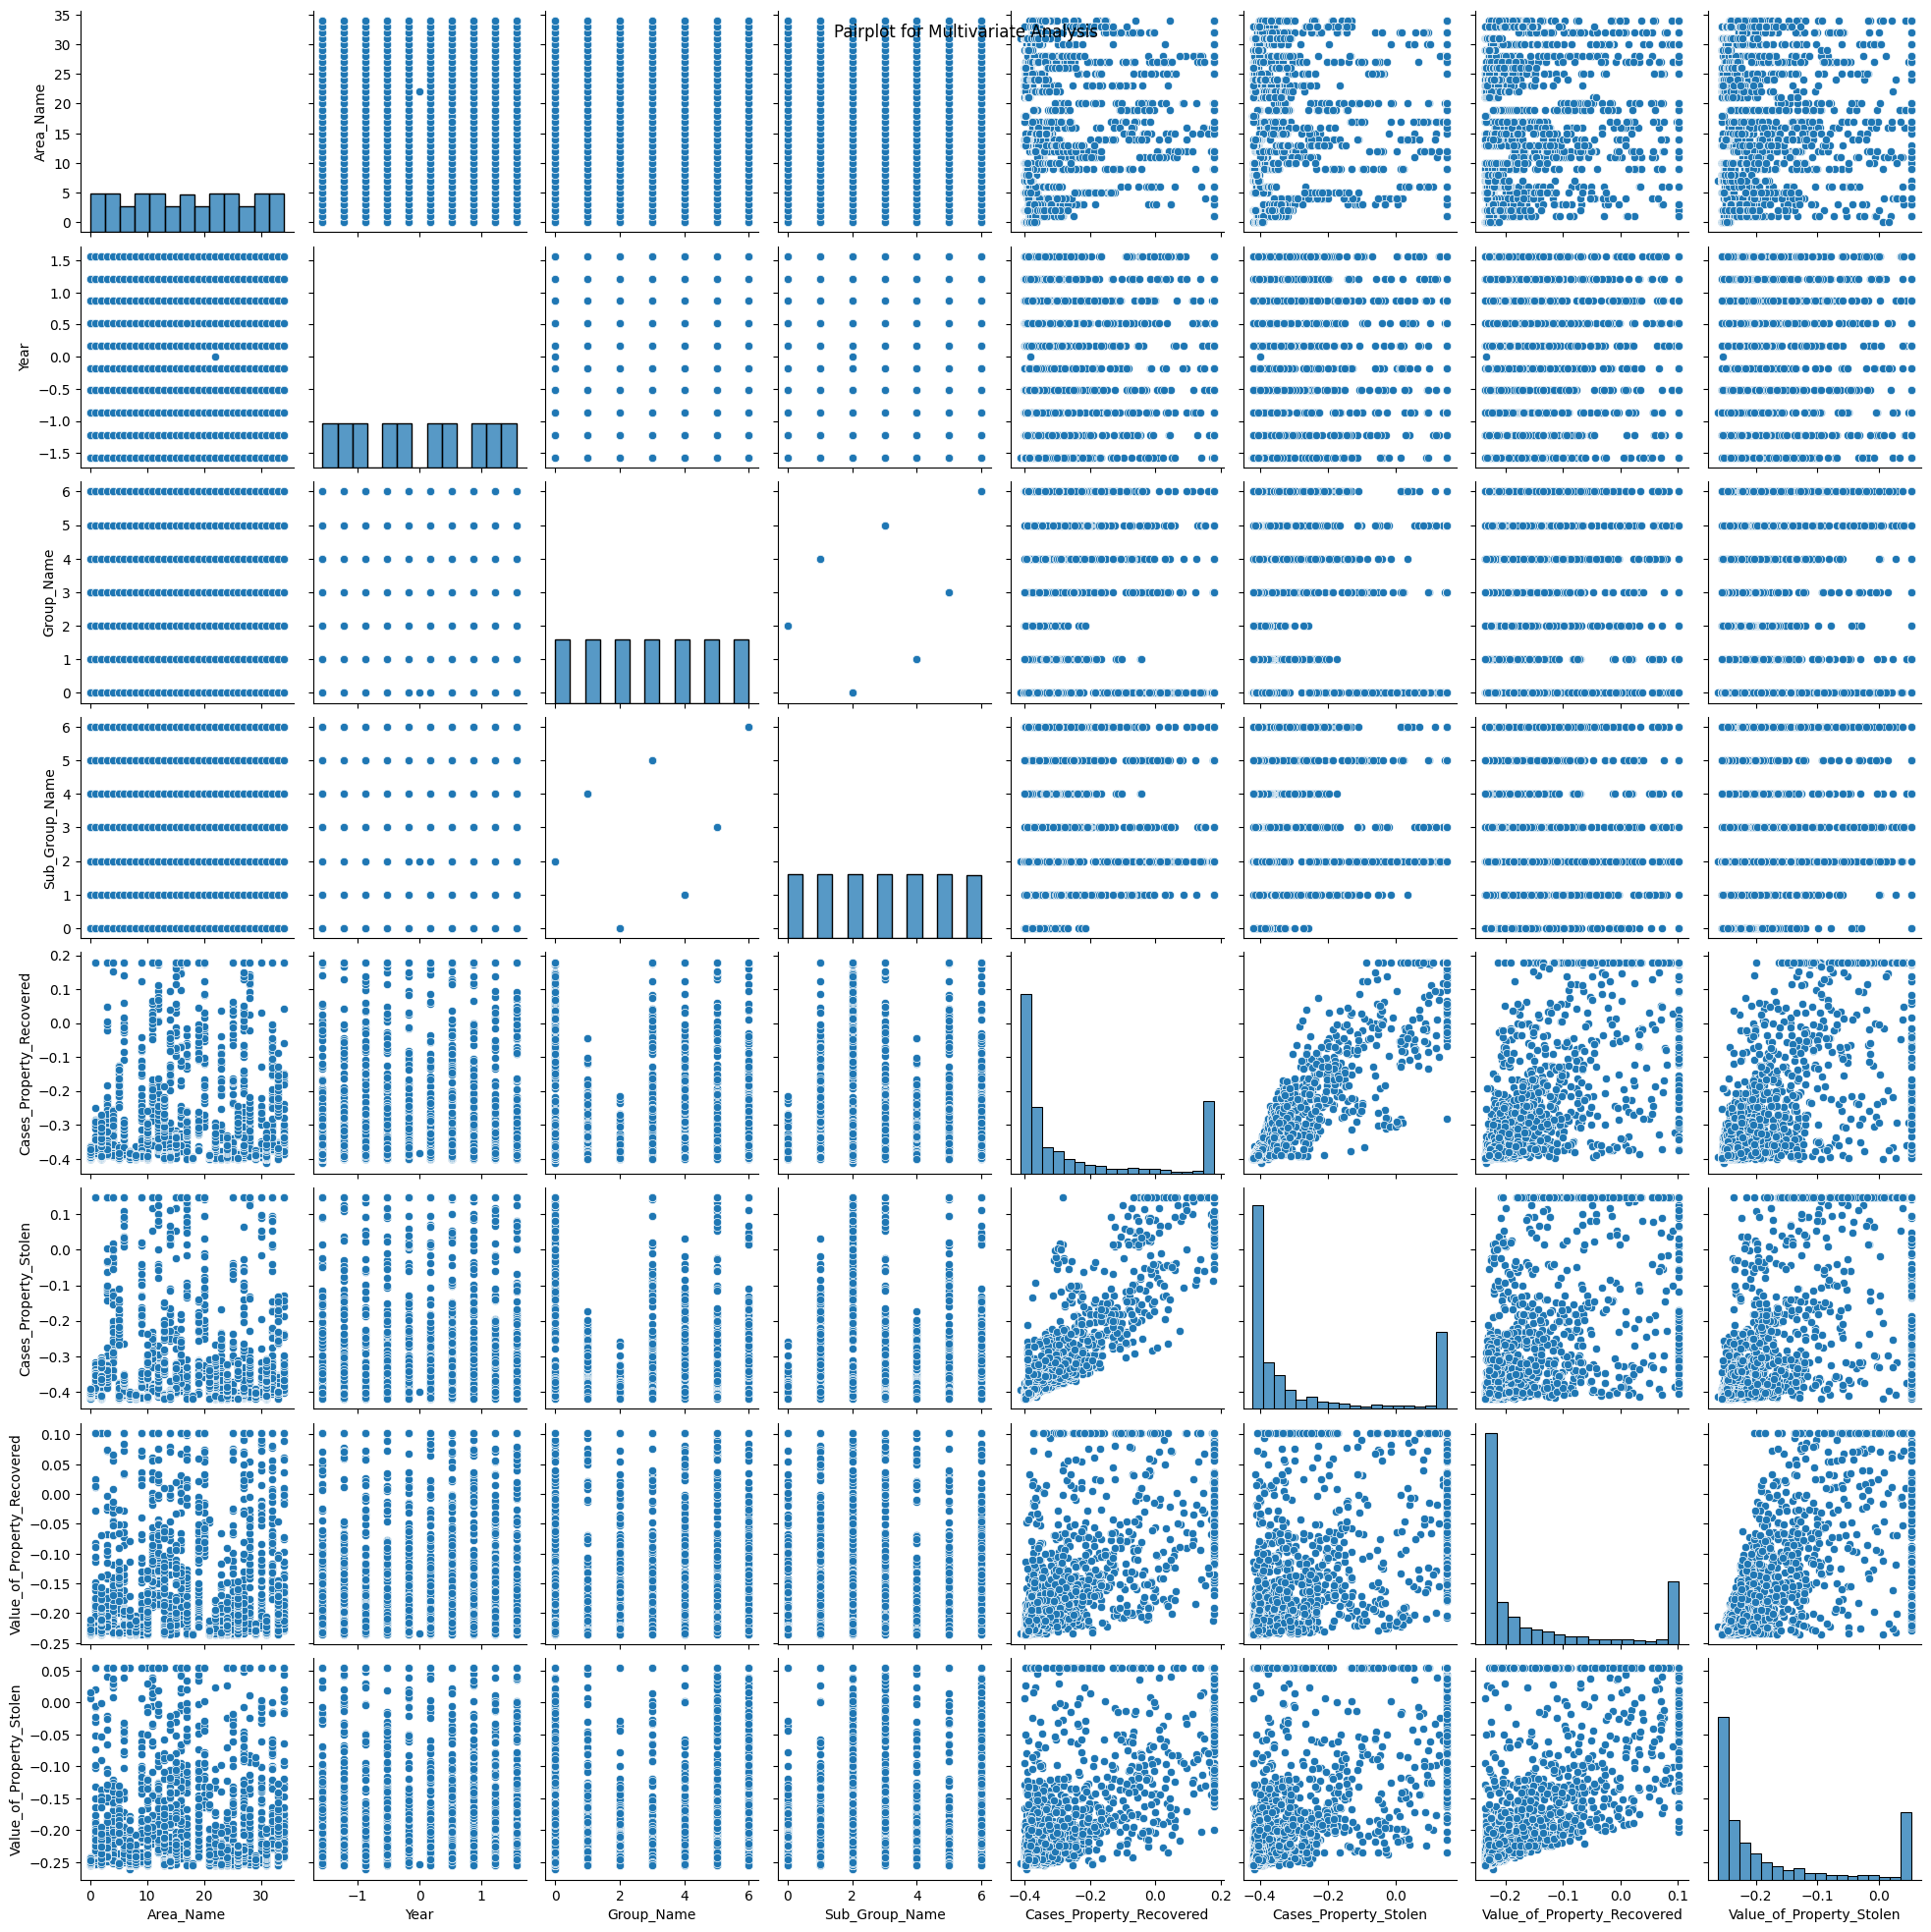

In [ ]:
# Step 8  Multivariate Analysis (Pairplot)

sns.pairplot(df)
plt.suptitle("Pairplot for Multivariate Analysis")
plt.show()


In [ ]:
# Step 9  Insights & Interpretation

print("Key Insights:")

if 'Cases_Property_Stolen' in df.columns and 'Cases_Property_Recovered' in df.columns:
    df['Recovery_Rate'] = (df['Cases_Property_Recovered'] / df['Cases_Property_Stolen']).replace([np.inf, -np.inf], 0)
    print(f"Average Property Recovery Rate: {df['Recovery_Rate'].mean():.2f}")

if 'State/UT' in df.columns:
    print("\nTop 5 States with Highest Property Theft Cases:\n", df['State/UT'].value_counts().head())

if 'Year' in df.columns:
    print("\nTrend Over Years:\n", df.groupby('Year')['Cases_Property_Stolen'].sum())


Key Insights:
Average Property Recovery Rate: 1.09

Trend Over Years:
 Year
-1.567678   -64.575491
-1.219400   -64.972120
-0.871122   -65.814449
-0.522844   -65.647999
-0.174566   -65.683772
-0.000427    -0.399457
 0.173712   -65.284490
 0.521991   -62.900300
 0.870269   -63.441989
 1.218547   -63.553857
 1.566825   -63.438670
Name: Cases_Property_Stolen, dtype: float64
